In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Load the dataset
df = pd.read_csv('../data/tickets.csv')
print(df.head())
print(df.info())

   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue   
3          Female  Microsoft Office       2020-11-13  Billing inquiry   
4          Female  Autodesk AutoCAD       2020-02-04  Billing inquiry   

             Ticket Subject  \
0             Product setup   
1  Peripheral compatibil

In [3]:
# Explore the target variable
print("Unique Ticket Types:", df['Ticket Type'].unique())
print("Value counts:\n", df['Ticket Type'].value_counts())

# Check for missing values
print("Missing values:\n", df.isnull().sum())

Unique Ticket Types: <StringArray>
[     'Technical issue',      'Billing inquiry', 'Cancellation request',
      'Product inquiry',       'Refund request']
Length: 5, dtype: str
Value counts:
 Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64
Missing values:
 Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satis

In [4]:
# Download NLTK data
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Text preprocessing function
def preprocess_text(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    # Join back
    return ' '.join(tokens)

# Apply preprocessing
df['clean_description'] = df['Ticket Description'].apply(preprocess_text)
print(df[['Ticket Description', 'clean_description']].head())

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\shaik\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\shaik\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shaik\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                  Ticket Description  \
0  I'm having an issue with the {product_purchase...   
1  I'm having an issue with the {product_purchase...   
2  I'm facing a problem with my {product_purchase...   
3  I'm having an issue with the {product_purchase...   
4  I'm having an issue with the {product_purchase...   

                                   clean_description  
0  im issue productpurchased please assist billin...  
1  im issue productpurchased please assist need c...  
2  im facing problem productpurchased productpurc...  
3  im issue productpurchased please assist proble...  
4  im issue productpurchased please assist note s...  


In [6]:
# Split the data
X = df['clean_description']
y = df['Ticket Type']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Vectorize the text
vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Training data shape:", X_train_vec.shape)
print("Test data shape:", X_test_vec.shape)

Training data shape: (6775, 5000)
Test data shape: (1694, 5000)


In [7]:
# Train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

# Predict on test set
y_pred = model.predict(X_test_vec)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.1936245572609209
Classification Report:
                       precision    recall  f1-score   support

     Billing inquiry       0.17      0.12      0.14       357
Cancellation request       0.19      0.19      0.19       327
     Product inquiry       0.18      0.19      0.18       316
      Refund request       0.20      0.23      0.21       345
     Technical issue       0.22      0.24      0.23       349

            accuracy                           0.19      1694
           macro avg       0.19      0.19      0.19      1694
        weighted avg       0.19      0.19      0.19      1694

Confusion Matrix:
 [[43 67 75 93 79]
 [43 61 69 77 77]
 [50 56 59 77 74]
 [63 63 62 80 77]
 [47 80 62 75 85]]


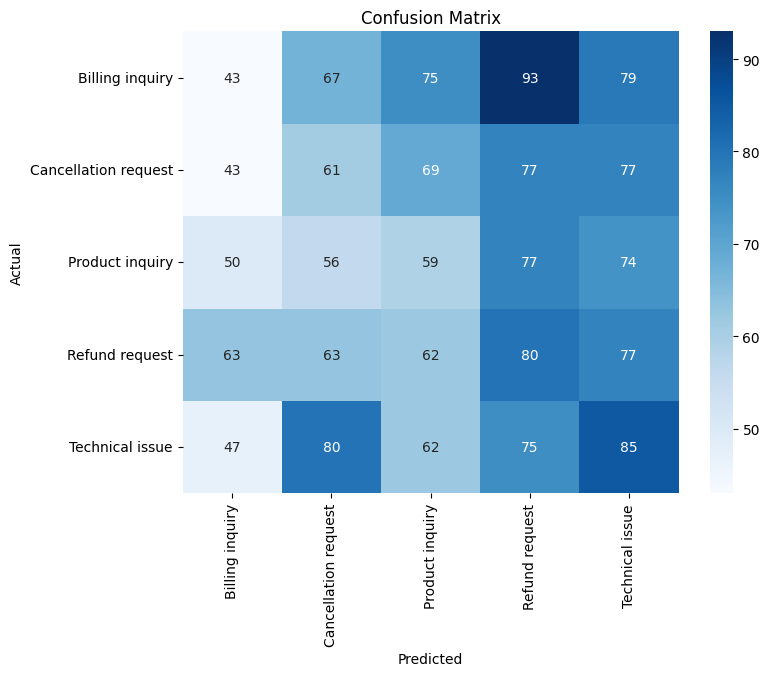

In [9]:
# Plot confusion matrix
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('../images/confusion_matrix.png')
plt.show()